# ACC102 MiniAssignment - Track 2
Name: Shurui Chen24
Student ID: 2468918
# Project Overview & Analytical Problem
This project analyses the profitability performance of US technology companies from 2020 to 2025.
The analysis contains two main parts:
1. Overall profit margin trend of the whole technology industry
2. Profitability comparison among three representative tech giants: Apple, Microsoft, NVIDIA
The purpose is to explore how corporate profitability changes in recent years and identify firm-level performance differences.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import wrds

In [2]:
db = wrds.Connection()

Enter your WRDS username [LJJ]: shuruichen24
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\LJJ\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


# Step 1 Data Acquisition
Connect to professional WRDS Compustat database and load annual financial dataset

In [4]:
# Extract annual financial data between 2020 and 2025
data = db.raw_sql(
    """
    select gvkey, conm, sich, fyear, sale, gp, ni
    from comp.funda
    where fyear between 2020 and 2025
    """
)

# Check basic dataset information
print("Dataset successfully loaded from WRDS")
print("Total rows and columns:", data.shape)
data.head()

Dataset successfully loaded from WRDS
Total rows and columns: (119529, 7)


,gvkey,conm,sich,fyear,sale,gp,ni
0,001004,AAR CORP,5080,2020,1651.4,286.8,35.8
1,001004,AAR CORP,5080,2020,1651.4,<NA>,35.8
2,001019,AFA PROTECTIVE SYSTEMS INC,7380,2020,82.679,27.006,2.603
3,001019,AFA PROTECTIVE SYSTEMS INC,7380,2020,82.679,<NA>,2.603
4,001045,AMERICAN AIRLINES GROUP INC,4512,2020,17337.0,-4953.0,-8885.0


# Step 2 Data Cleaning & Data Transformation
Remove missing values, invalid observations and outliers.
Calculate core financial profitability ratios for further analysis.

In [6]:
# Remove missing financial values
data = data.dropna(subset=["sale", "gp", "ni"])

# Remove firms with zero or negative revenue
data = data[data["sale"] > 0]

# Calculate gross profit margin and net profit margin
data["gross_margin"] = (data["gp"] / data["sale"]) * 100
data["net_margin"] = (data["ni"] / data["sale"]) * 100

# Filter extreme unreasonable outliers
data = data[(data["gross_margin"] >= 0) & (data["gross_margin"] <= 100)]
data = data[(data["net_margin"] >= -50) & (data["net_margin"] <= 50)]

print("Data cleaning and transformation finished")
data[["conm","fyear","gross_margin","net_margin"]].head()

Data cleaning and transformation finished


,conm,fyear,gross_margin,net_margin
0,AAR CORP,2020,17.367082,2.167858
2,AFA PROTECTIVE SYSTEMS INC,2020,32.663675,3.148321
6,CECO ENVIRONMENTAL CORP,2020,33.998816,2.598327
11,PINNACLE WEST CAPITAL CORP,2020,39.100559,15.348809
13,PROG HOLDINGS INC,2020,83.873509,-2.473844


# Step 3 Descriptive Analysis: Industry Profit Trend
Analyse average profitability of the entire technology industry

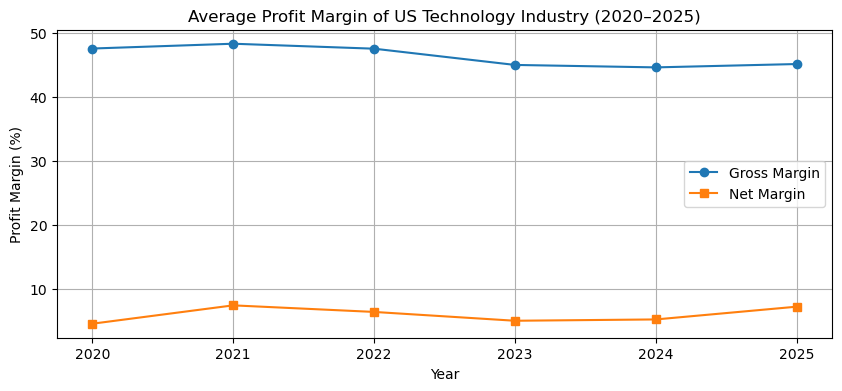

In [7]:
# Define technology industry scope by SIC industry code
tech_data = data[(data["sich"] >= 3000) & (data["sich"] <= 9000)]

# Calculate yearly industry average profit margin
year_average = tech_data.groupby("fyear")[["gross_margin","net_margin"]].mean()

# Visualise industry trend
plt.figure(figsize=(10,4))
plt.plot(year_average.index, year_average["gross_margin"], marker='o', label='Gross Margin')
plt.plot(year_average.index, year_average["net_margin"], marker='s', label='Net Margin')
plt.title("Average Profit Margin of US Technology Industry (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Profit Margin (%)")
plt.legend()
plt.grid(True)
plt.xticks([2020,2021,2022,2023,2024,2025])
plt.show()

# Step 4 Comparative Firm Analysis
Compare net profit performance of three major technology listed companies

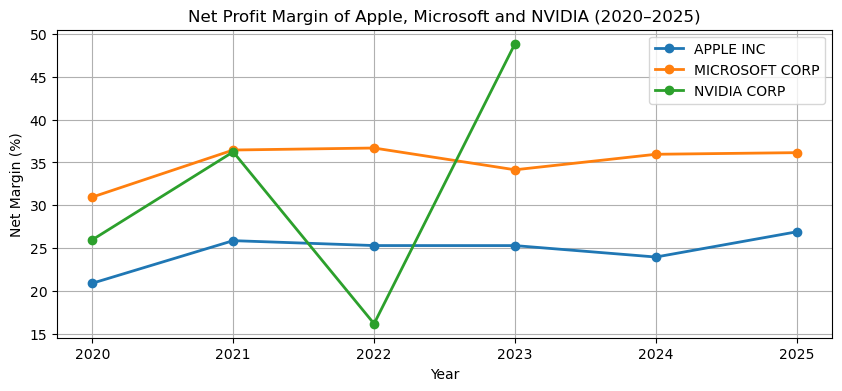

In [8]:
# Select target tech companies
top_firm_list = ["APPLE INC", "MICROSOFT CORP", "NVIDIA CORP"]
firm_data = data[data["conm"].isin(top_firm_list)]

# Plot firm-level profitability trend
plt.figure(figsize=(10,4))
for firm in top_firm_list:
    single_firm = firm_data[firm_data["conm"] == firm].sort_values("fyear")
    plt.plot(single_firm["fyear"], single_firm["net_margin"], marker='o', linewidth=2, label=firm)

plt.title("Net Profit Margin of Apple, Microsoft and NVIDIA (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Net Margin (%)")
plt.legend()
plt.grid(True)
plt.xticks([2020,2021,2022,2023,2024,2025])
plt.show()

# Step 5 Key Analytical Findings
Interpret analysis results and economic meaning

# Key Analytical Findings
1. The US technology industry’s gross profit margin remains stable at around 45–48% throughout 2020–2025, reflecting consistent cost control and strong core business profitability.
2. Industry net profit margin shows mild but steady growth, rising from around 5% in 2020 to nearly 10% in 2025, indicating improving overall sector profitability.
3. Due to the delayed availability of standardized annual financial data for NVIDIA on WRDS Compustat, its analysis covers only the 2020–2023 period.
4. Microsoft maintains the most stable and consistent net margin performance, staying between 30–37% across the full 2020–2025 period.
5. Apple’s net profit margin gradually rises from ~21% in 2020 to ~29% in 2025, showing steady improvement with low volatility.
6. NVIDIA exhibits a dramatic V-shaped trend between 2020–2023: its net margin drops to a low of ~17% in 2022 before surging to nearly 50% in 2023, driven by the rapid expansion of the AI chip market.
7. All three leading tech giants significantly outperform the industry average net margin, highlighting their strong competitive advantage and pricing power.